# Exploring PDE constrained optimisation

This notebook will document my process of exploring PDE constrained optimisation through mathematics and implementation in pure Python.

## An initial problem

Let's look at a Poisson optimal control problem. 

The Poisson equation is one of the most fundamental PDEs in matehmatical physics. It reads

$$-\nabla^2\varphi = q,$$

where $\varphi$ and $q$ are real or complex valued functions. We use the minus sign here to ensure $\nabla^2$ is positive definite, which guarantees a unique solution. Explictly, in 3D Cartesian space this looks like

$$-\left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} + \frac{\partial^2}{\partial z^2}\right)\varphi(x, y, z) = q(x, y, z).$$

Poisson's equation has applications across gravity, fluid dynamics, thermodynamics, and more. 

In this notebook, we will consider that $\varphi$ is a 2D steady state temperature field and $q$ is a heat source/ sink distribution (e.g., $q > 0$ at a point means heat injection, $q < 0$ means heat absoprtion). For some domain $\Omega \subset \mathbb{R}^{2}$ with boundary $\delta\Omega$, we will say that we want our temperature to be zero at the boundaries, i.e., our problem in full is

$$-\nabla^2 \varphi = q \in \Omega,\;\;\;\; \varphi = 0 \text{ on } \delta\Omega.$$

### PDE constrained optimiation

PDE constrained optimisation problems usually take the form

$$\text{minimise } J(u, m) \text{  subject to  } g(u, m) = 0,$$

where $J$ is the functional, $g$ is the constraint expressing our PDE and boundary conditions, and $u$ and $m$ are model parameters.  

In the case that our constraint is a PDE (and associated initial and boundary conditions), our workflow might be

$$\underbrace{m}_\text{input} \;\; \rightarrow \;\; \underbrace{g(u, m)}_\text{PDE constraint} \;\; \rightarrow \;\; \underbrace{u}_\text{output}\;\; \rightarrow \underbrace{J(u, m)}_\text{functional}.$$

In this case our objective is to find $\frac {\partial J} {\partial m}.$ We want to figure out how our objective varies with respect to particular model parameters in order to update those parameters.

In the context of our problem, the optimal control problem is such that we are allowed to choose $f$ and we want to choose it so that the resulting temperature $\varphi$ is as close as possible to some desired target profile $\hat{\varphi}$. In essence, we want to minimise the difference between a given and target temperature profile subject to the Poisson equation (and specified boundary conditions).

### An intuitive formulation

Let's make this formulation concrete and interpretable.

Consider a top down view of a square room with side lengths of $1m$. Let's say it is freezing outside, such that the temperature of the walls is $0$. Inside the room there are sources and sinks (radiators, or people), each with a fixed heat output magnitude $Q$. They radiate or cool, and $f$ describes their distribution in the room. The question is: where should we place these to make the room temperature $\varphi$ as close to the desired profile $\hat{\varphi}$ as possible?

More formally, consider a domain $\Omega = [0, 1]^2$ subject to the boundary conditions

$$\varphi(x, 0) = 0\\ \varphi(x, 1) = 0 \\ \varphi(0, y) = 0 \\ \varphi(1, y) = 0.$$

If we let $q$ represent our heat source/sink distribution, our problem then is 

$$\text{minimise } J(\varphi, q) = \frac 1 2 \int_\Omega (\varphi - \hat{\varphi})^2\ dx dy + \frac \beta 2 \int_\Omega q^2\ dxdy \\
\text{subject to  } g(\varphi, f) = \begin{cases}
-\nabla^2 \varphi - q = 0\\
\varphi = 0 \text{ on } \delta \Omega
\end{cases}.$$

In the functional, the first term measures how well the temperature matches the target profile, while the second penalises excessive heating or cooling. Here, $\beta$ is a regularisation parameter which punishes large field values.

For simplicity, we will treat $f$ as a continuous field across the whole room that represents source/sink placement. Rather than optimising placement directly, the optimiser will be allowed to distribute heating and cooling across the whole room and positioning will be implied by regions that are strongly positive/negative. This is for simplicity and mathematical convenience.

### Discretisation

Notice the above formulation is continuous. To solve this problem on a finite machine, we must of course discretise our problem. Consider our domain is broken down into $N + 2$ points in each direction (+2 ghost nodes to handle boundary conditions). Then our grid spacing is

$$x_i = ih,\;\;\;\; y_j = jh,$$

$i, j = 0, 1, \dots, N$, $h = 1/N+1$.

Now, our PDE is

$$-\nabla^2\varphi(x, y) - q(x, y) = 0$$

Since our domain is uniform and a simple shape, we can just use finite differences to discretise our equation. We won't concern ourselves with the implementation here, but just know the Laplacian can be written in discrete form using second order central differences as

$$\nabla^2 \varphi(x_i, y_j) = \frac{\varphi_{i+1, j} + \varphi_{i-1, j} + \varphi_{i, j+1} + \varphi_{i, j-1} - 4\varphi_{i, j}}{h^2},$$

where we have used the notation that $\varphi(x+h, y) := \varphi_{i+1, j}$ for convience. Now, we can write our PDE in discrete form as

$$-\frac{\varphi_{i+1, j} + \varphi_{i-1, j} + \varphi_{i, j+1} + \varphi_{i, j-1} - 4\varphi_{i, j}}{h^2} - q_{i, j} = 0.$$

Note that we can write this problem in the form 

$$A\varphi - q = 0,$$

where $A$ is a (block) tridiagonal discretisation matrix (with tridiagonal blocks) of the form

$$
A = \frac{1}{h^2}
\begin{bmatrix}
B & -I & 0 & \cdots & 0 \\
-I & B & -I & \ddots & \vdots \\
0 & -I & B & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -I \\
0 & \cdots & 0 & -I & B
\end{bmatrix},
$$

where $I$ is the $N \times N$ identity matrix and $B$ is the tridiagonal block

$$
B =
\begin{bmatrix}
4 & -1 & 0 & \cdots & 0 \\
-1 & 4 & -1 & \ddots & \vdots \\
0 & -1 & 4 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -1 \\
0 & \cdots & 0 & -1 & 4
\end{bmatrix}.
$$

We can use a similar approach to express our boundary conditions, which become

$$\varphi_{0, j} = \varphi_{N+1, j} = \varphi_{i, 0} = \varphi_{i, N+1} = 0.$$

Since we are considering $N+2$ points, our continuous integrals in the functional simply become discrete summations, and our fully discretised optimisation problem becomes

$$
\begin{align*}
    \text{minimise } & J(\varphi, q) = \frac {h^2} 2 \sum_{i, j} (\varphi_{i, j} - \hat{\varphi_{i, j}})^2 + \frac {h^2\beta} 2 \sum_{i, j} q_{i, j}^2 \\[5pt]
    
    \text{subject to  } & g(\varphi, q) = A\varphi - q = 0\\
\end{align*}$$

Note that we have now incorporated our boundary conditions into the discretisation matrix, hence why they 'dissapear' from the problem statement. 

## The reduced problem

Our task is to minimise $J(\varphi, q)$. For each source field $q$, the Poisson equation has a unique solution $\varphi$. This means we can actually write

$$\varphi = \varphi(q).$$

Instead of treating $\varphi$ and $q$ as separate unknowns, in this way we can manipulate the PDE such that once $q$ is known, $\varphi$ is determined. 

In this reduced form, the functional becomes

$$J(\varphi(x, y), q(x, y)) \Rightarrow J(\varphi(q), q).$$

This is the form of our reduced problem - now it says "choose the heating/ cooling field $q$, and the room temperature $\varphi$ is whatever the PDE says it must be". This is contrary to the original formulation in which $q$ and $\varphi$ can vary independently of eachother.

The main benefit of this is that the PDE constraint is enforced exactly during optimisation, since every time we evaluate $J$ we compute $\varphi(q)$ by solving the PDE. This gives us one less thing to worry about, since we don't need to worry about separately maintaining the $\varphi$ and $q$.

At this stage, we can start to eastablish what our optimisation loop will look like:

1. Guess $q$
2. Solve the PDE for $\varphi(q)$
3. Evaluate $J$
4. Compute the gradient
5. Update $q$

## The adjoint equation

In the steps above, a gradient is mentioned. This gradient is teh gradient of the functional with respect to the input field $q$, $\frac {dJ}{dq}$. This tells us the direction(s) in which to propagate the input variable in order to move the value of $J$ towards a minimum value.

Note our problem is not just "minimise $J$", it is "minimise $J$ subject to the PDE". Thus in order to optimise while handling the PDE constraint we need a way to package the PDE and the constraint together cleanly. This packaging is the _Lagrangian_:

$$\mathcal{L}(\mathbf{\varphi}, \bf q, \mathbf{\lambda}) = J(\mathbf{\varphi}, q) - \mathbf{\lambda}^T g(\mathbf{\varphi}, q).$$

We need a way to obtain the gradient of the functional with respect to all of the control variables directly, in a manner that is efficient. This is the _adjoint equation_, which we can obtain by finding the stationary points of the Lagrangian. Taking partial derivatives and setting to zero reveals

$$
\begin{align*}
\text{The PDE constraint } & \frac {\partial \mathcal{L}}{\partial \lambda} = g(\mathbf{\varphi, q}) = 0,\\
\text{The $q$ equation } & \frac {\partial \mathcal{L}}{\partial q} = \frac{\partial J(\varphi, q)}{\partial q} - \lambda^T\frac{\partial g(\varphi, q)}{\partial q} =  0,\\
\text{The adjoint equation } & \frac {\partial \mathcal{L}}{\partial \varphi} = \frac{\partial J(\varphi, q)}{\partial \varphi} - \lambda^T\frac{\partial g(\varphi, q)}{\partial \varphi}= 0.
\end{align*}
$$

These three are the neccesary conditions for optimality. Here, we see that formulating the problem in this way automatically enforces the PDE constraint by the first equation!

The adjoint variable $\lambda$ was introduced intentionally: it removes the need to differentiate the state variable $\varphi$ with respect to every control variable directly, which would be very costly. The adjoint equation gives the gradient of the objective w.r.t. all control variables at a very low cost.

IN the context of our problem, the 3 equations are

$$
A\varphi - q = 0\\
\lambda - \beta h^2 q = 0\\
h^2(\varphi - \hat{\varphi}) + A^T\lambda = 0\\
$$

The first equation is the PDE: the forward model. The second is the optimality condition: it basically says what the optimum point means for the control variable. The third is the adjoint: this tells us where changing the heating/ cooling would help the obective the most. 

## Implementation

That wraps up most of the maths for now! We have pretty much everything we need to solve, and our problem is clearly stated. Concerning implementation, our algorithm will be, at a high level, as follows

1. Guess a control $\bf q^{(k)}$
2. Solve $A\bf \varphi^{(k)} = q^{(k)}$ for $\bf \varphi^{(k)}$
3. Compute the residual $\bf r^{(k)} = \varphi^{(k)} - \hat{\varphi}$
3. Solve the adjoint equation, $A\lambda^{(k)} = h^2 \bf r^{(k)}$ to get $\bf \lambda^{(k)}$
4. Use the optimality condition to build the reduced gradient, $\bf g^{(k)} = \beta h^2 \mathbf{q}^{(k)} - \lambda^{(k)}$
5. Update the control using gradient descent, L-BFGS, or another optimiser

Clearly now we have some things to choose, namely 

- the grid size $N$
- the regularisation parameter $\beta$
- the target profile $\hat{\varphi}$
- the initial guess $\bf q^{(0)}$

To faciliatate this first stage of implementation, let's write ourselves a data class to represent our computational domain.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

In [70]:
@dataclass
class Domain2D:

    Lx: float = 1.0  # X length
    Ly: float = 1.0  # Y length
    Nx: int = 101    # number of X nodes 
    Ny: int = 101    # number of Y nodes
    
    _data: np.ndarray = field(default_factory=lambda: np.empty(0))  # field data
    _init_data: np.ndarray = field(default_factory=lambda: np.empty(0), init=False)  # store initial field

    # input validation
    def __post_init__(self):
        if self.Lx <= 0 or self.Ly <= 0:
            raise ValueError("Lx and Ly must be positive.")
        if self.Nx <= 0 or self.Ny <= 0:
            raise ValueError("Nx and Ny must be positive integers.")
        
        # if initial state not provided (empty array), use random numbers (normal dist)
        if self._data.size == 0:
            self._data = np.random.rand(self.Nx * self.Ny)

        # flatten if 2D
        if len(self._data.shape) > 1:
            self._data = self._data.reshape(-1)
        
        # catch dimension arg mismatch
        if self._data.size != self.Nx * self.Ny:
            raise ValueError(
                f"Provided data size {self._data.size} does not match "
                f"provided dimensions ({self.Nx}, {self.Ny})"
            )

        self._init_data = self._data.copy() # save init field

    # plot the field and grid nodes
    def show(self, interpolate=True):
        data = self._data.reshape(self.Nx, self.Ny) # unflatten

        vmin = data.min()
        vmax = data.max()

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(data, 
                       origin="lower", 
                       extent=(0.0, self.Lx, 0.0, self.Ly), 
                       interpolation="bicubic" if interpolate else None,
                       vmin=vmin,
                       vmax=vmax
                    )

        # formatting
        ax.set_xlabel(r"$x$", fontsize=12)
        ax.set_ylabel(r"$y$", fontsize=12)
        title = "2D Computational domain"

        if interpolate: title += " (interpolated)"

        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, label="Field value", orientation="horizontal")
        cbar.set_ticks(np.linspace(vmin, vmax, 5))

Cool, now we have a dataclass representation of our discrete domain and a way to see what the field looks like. This class represents the parameters of our domain: size, shape, and data. Let's instanttiate an object of this class and take a look at its default values (random samples from the normal distribution).

In [71]:
d = Domain2D()

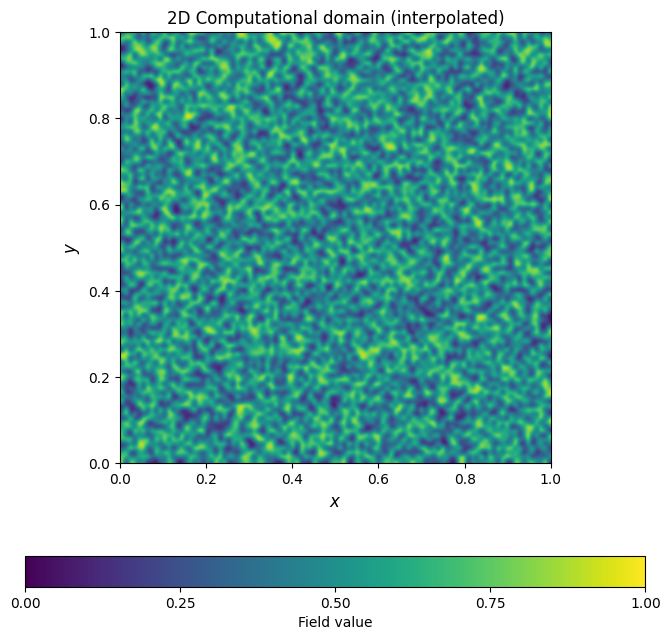

In [72]:
d.show()